#  Wind Power Forecasting for Renewable Energy Systems Using LSTM Networks

## 1. Introduction
The precise prediction of renewable energy production is vital for optimizing power system performance. The production of wind energy is unpredictable and relies heavily on temporal characteristics like climate and season.

In this study, our objective is to predict the hourly wind energy production in Germany using an LSTM model, which belongs to the class of RNN. An LSTM model is ideal for predicting time series data since it can learn temporal relations better than other predictive models such as MLP and CNN.

---

## 2. Dataset and Preprocessing

### 2.1 Dataset
The dataset is obtained from Open Power System Data (2020), which provides real-world electricity data for European countries.  

For this study, only the Germany wind generation data (`DE_wind_generation_actual`) is used.

- Number of instances: ~50,000 hourly observations  
- Feature used: Wind generation (MW)  
- Time range: Multiple years of hourly data  

### 2.2 Preprocessing
The following preprocessing steps were applied:
- Missing values were removed to ensure clean input data  
- The data was normalized using MinMaxScaler to improve model performance  
- The time series was converted into sequences of 24 time steps to predict the next value  

These steps are necessary to ensure stable and efficient training of the LSTM model.


## 3. Training

The model was trained using:
- Optimizer: Adam  
- Loss function: Mean Squared Error (MSE)  
- Epochs: 20  
- Batch size: 32  

A validation split of 20% was used to monitor performance during training.

The training and validation loss curves show that the model converges well without significant overfitting.

---


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
# Load the Open Power System Data CSV file into a pandas DataFrame
# - parse_dates=True ensures that the index is treated as datetime objects
# - index_col=0 sets the first column (utc_timestamp) as the DataFrame index
# This allows easy time-series operations and plotting later
df = pd.read_csv("time_series_60min_singleindex.csv", parse_dates=True, index_col=0)

# Display the first few rows to check that the data loaded correctly
print(df.head())

                                 cet_cest_timestamp  \
utc_timestamp                                         
2014-12-31 23:00:00+00:00  2015-01-01T00:00:00+0100   
2015-01-01 00:00:00+00:00  2015-01-01T01:00:00+0100   
2015-01-01 01:00:00+00:00  2015-01-01T02:00:00+0100   
2015-01-01 02:00:00+00:00  2015-01-01T03:00:00+0100   
2015-01-01 03:00:00+00:00  2015-01-01T04:00:00+0100   

                           AT_load_actual_entsoe_transparency  \
utc_timestamp                                                   
2014-12-31 23:00:00+00:00                                 NaN   
2015-01-01 00:00:00+00:00                              5946.0   
2015-01-01 01:00:00+00:00                              5726.0   
2015-01-01 02:00:00+00:00                              5347.0   
2015-01-01 03:00:00+00:00                              5249.0   

                           AT_load_forecast_entsoe_transparency  \
utc_timestamp                                                     
2014-12-31 23:00:00+00:0

In [ ]:
# Print shape of dataset
print("Dataset shape:", df.shape)

Dataset shape: (50401, 299)


In [ ]:
# List all columns in the DataFrame that start with 'DE'
# This helps us identify all Germany-related variables in the dataset
germany_columns = [col for col in df.columns if col.startswith("DE")]
print(germany_columns)

['DE_load_actual_entsoe_transparency', 'DE_load_forecast_entsoe_transparency', 'DE_solar_capacity', 'DE_solar_generation_actual', 'DE_solar_profile', 'DE_wind_capacity', 'DE_wind_generation_actual', 'DE_wind_profile', 'DE_wind_offshore_capacity', 'DE_wind_offshore_generation_actual', 'DE_wind_offshore_profile', 'DE_wind_onshore_capacity', 'DE_wind_onshore_generation_actual', 'DE_wind_onshore_profile', 'DE_50hertz_load_actual_entsoe_transparency', 'DE_50hertz_load_forecast_entsoe_transparency', 'DE_50hertz_solar_generation_actual', 'DE_50hertz_wind_generation_actual', 'DE_50hertz_wind_offshore_generation_actual', 'DE_50hertz_wind_onshore_generation_actual', 'DE_LU_load_actual_entsoe_transparency', 'DE_LU_load_forecast_entsoe_transparency', 'DE_LU_price_day_ahead', 'DE_LU_solar_generation_actual', 'DE_LU_wind_generation_actual', 'DE_LU_wind_offshore_generation_actual', 'DE_LU_wind_onshore_generation_actual', 'DE_amprion_load_actual_entsoe_transparency', 'DE_amprion_load_forecast_entsoe_t

In [ ]:
# - 'DE_wind_generation_actual' represents the total actual wind power generation in Germany (MW)
# - This simplifies the dataset to a univariate time series for LSTM forecasting
df = df[['DE_wind_generation_actual']]

In [ ]:
print("Number of rows (instances):", df.shape[0])
print("Number of columns (features):", df.shape[1])

Number of rows (instances): 50401
Number of columns (features): 1


In [ ]:
print("Start date:", df.index.min())
print("End date:", df.index.max())

Start date: 2014-12-31 23:00:00+00:00
End date: 2020-09-30 23:00:00+00:00


In [ ]:
df = df.dropna()

In [ ]:
df.index = pd.to_datetime(df.index)

In [ ]:
df.index

DatetimeIndex(['2015-01-01 00:00:00+00:00', '2015-01-01 01:00:00+00:00',
               '2015-01-01 02:00:00+00:00', '2015-01-01 03:00:00+00:00',
               '2015-01-01 04:00:00+00:00', '2015-01-01 05:00:00+00:00',
               '2015-01-01 06:00:00+00:00', '2015-01-01 07:00:00+00:00',
               '2015-01-01 08:00:00+00:00', '2015-01-01 09:00:00+00:00',
               ...
               '2020-09-30 14:00:00+00:00', '2020-09-30 15:00:00+00:00',
               '2020-09-30 16:00:00+00:00', '2020-09-30 17:00:00+00:00',
               '2020-09-30 18:00:00+00:00', '2020-09-30 19:00:00+00:00',
               '2020-09-30 20:00:00+00:00', '2020-09-30 21:00:00+00:00',
               '2020-09-30 22:00:00+00:00', '2020-09-30 23:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='utc_timestamp', length=50326, freq=None)

In [ ]:
df

,DE_wind_generation_actual
utc_timestamp,
2015-01-01 00:00:00+00:00,8852.0
2015-01-01 01:00:00+00:00,9054.0
2015-01-01 02:00:00+00:00,9070.0
2015-01-01 03:00:00+00:00,9163.0
2015-01-01 04:00:00+00:00,9231.0
...,...
2020-09-30 19:00:00+00:00,10654.0
2020-09-30 20:00:00+00:00,11836.0
2020-09-30 21:00:00+00:00,12168.0


In [ ]:
# Keeping only the Germany wind generation column and remove any missing values (NaNs) to prepare a clean time series for LSTM
df = df[['DE_wind_generation_actual']].dropna()

In [ ]:
# Checking for any remaining missing values in the dataset to ensure the LSTM model receives clean input
print(df.isna().sum())

DE_wind_generation_actual    0
dtype: int64


In [ ]:
# Resample the data to hourly intervals, taking the mean if multiple entries exist per hour
# Ensures a consistent time step for LSTM time-series modeling
df = df.resample('H').mean()

/tmp/ipykernel_164/110589848.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample('H').mean()


In [ ]:

print(df.describe())

       DE_wind_generation_actual
count               50326.000000
mean                11552.234650
std                  9076.350769
min                   135.000000
25%                  4506.000000
50%                  9015.000000
75%                 16113.750000
max                 46064.000000


In [ ]:
# Scale the wind generation data to the range [0, 1] using MinMaxScaler
# - Scaling helps the LSTM converge faster and improves numerical stability
# - 'data_scaled' is a NumPy array ready for sequence creation
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df.values.reshape(-1, 1))

In [ ]:
data_scaled = np.clip(data_scaled, 0, 1)  # ensure no values outside 0–1

In [ ]:
# Create input-output sequences of 24 hours for LSTM; skip sequences with any NaNs
def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        seq_x = data[i:i+seq_length]
        seq_y = data[i+seq_length]
        if not (np.isnan(seq_x).any() or np.isnan(seq_y).any()):
            X.append(seq_x)
            y.append(seq_y)
    return np.array(X), np.array(y)

seq_length = 24
X, y = create_sequences(data_scaled, seq_length)

# Train/test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

X_train shape: (40164, 24, 1)
y_train shape: (40164, 1)
X_test shape : (10042, 24, 1)
y_test shape : (10042, 1)


---

## 3. Model Architecture

The model used in this project is a Long Short-Term Memory (LSTM) network.

### Architecture:
- Input: Sequence of 24 time steps  
- LSTM layer: 50 units (captures temporal dependencies)  
- Dropout layer: 0.2 (prevents overfitting)  
- Dense layer: 1 unit (predicts wind generation)

The LSTM layer uses internal memory mechanisms to learn long-term dependencies in time-series data, making it suitable for this forecasting task.

---

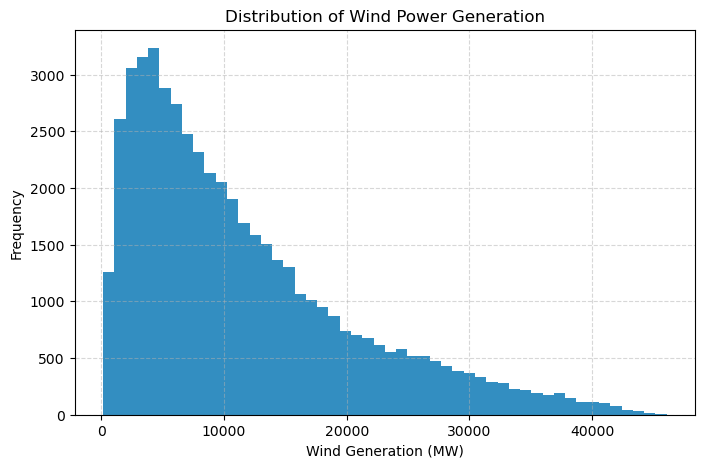

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['DE_wind_generation_actual'], bins=50, color='#0072B2', alpha=0.8)
plt.xlabel('Wind Generation (MW)')
plt.ylabel('Frequency')
plt.title('Distribution of Wind Power Generation')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# Define a simple LSTM model with 50 units, 20% dropout, and a single output; compile with Adam optimizer and MSE loss
model = Sequential([
    LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])

# Use lower learning rate to avoid NaNs
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse')
model.summary()

[HAMI-core Msg(164:140209796111680:libvgpu.c:839)]: Initializing.....
[HAMI-core Msg(164:140209796111680:libvgpu.c:855)]: Initialized
I0000 00:00:1775150331.158395     164 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5874 MB memory:  -> device: 0, name: NVIDIA H200 NVL, pci bus id: 0000:42:00.0, compute capability: 9.0
/opt/conda/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the LSTM on training data for 20 epochs with 32 batch size and 20% of data for validation
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)

Epoch 1/20
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - loss: 0.0024 - val_loss: 0.0010
Epoch 2/20
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - loss: 7.7575e-04 - val_loss: 5.4990e-04
Epoch 3/20
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - loss: 5.2493e-04 - val_loss: 3.6301e-04
Epoch 4/20
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - loss: 4.1227e-04 - val_loss: 2.7881e-04
Epoch 5/20
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 31s 31ms/step - loss: 3.5927e-04 - val_loss: 2.4373e-04
Epoch 6/20
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 34s 33ms/step - loss: 3.4078e-04 - val_loss: 2.2085e-04
Epoch 7/20
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 34s 33ms/step - loss: 3.2532e-04 - val_loss: 2.1960e-04
Epoch 8/20
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 34s 34ms/step - loss: 3.2127e-04 - val_loss: 2.4960e-04
Epoch 9/20
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 34s 33ms/step - loss: 3.1564e-04 - val_loss: 2.0835e-04
Epoch 10/20
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - loss: 3.1348e-04 - val_loss: 2.0526e-04
Epoch 11/20
1005/1005 ━━━━━

In [ ]:
import joblib

# Save model and scaler
model.save("lstm_wind_model.keras")
joblib.dump(scaler, "scaler.save")

['scaler.save']

In [ ]:
from tensorflow.keras.models import load_model
import joblib

# Load model and scaler
model = load_model("lstm_wind_model.keras")
scaler = joblib.load("scaler.save")

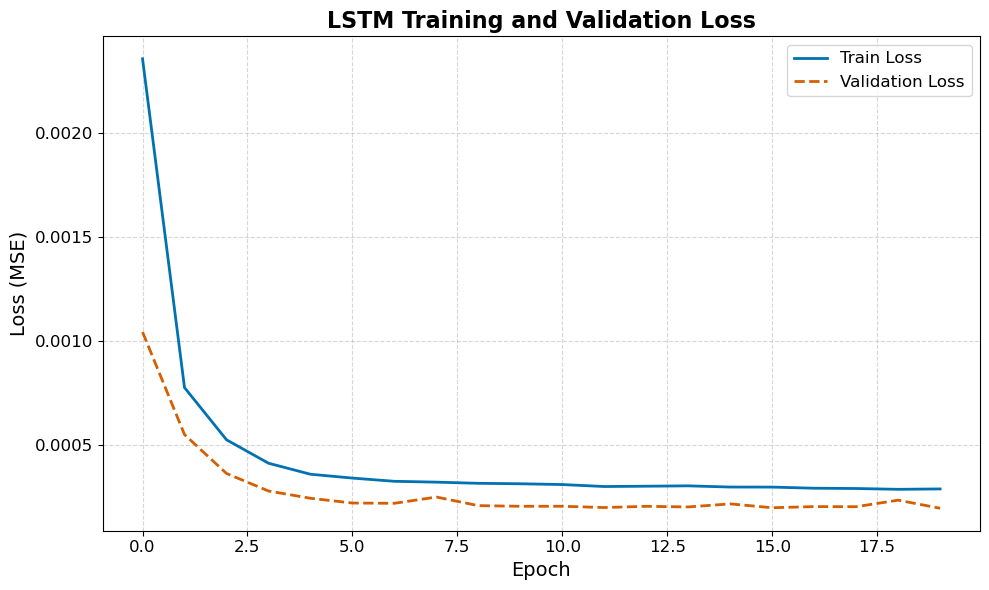

In [ ]:
import matplotlib.pyplot as plt

train_color = '#0072B2'  # blue
val_color = '#D55E00'    # orange

plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Train Loss', color=train_color, linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color=val_color, linewidth=2, linestyle='--')

# Add grid and title
plt.grid(True, linestyle='--', alpha=0.5)
plt.title('LSTM Training and Validation Loss', fontsize=16, weight='bold')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss (MSE)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Predict
y_pred = model.predict(X_test)

# Rescale back to MW
y_pred_rescaled = scaler.inverse_transform(y_pred)
y_test_rescaled = scaler.inverse_transform(y_test)

314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


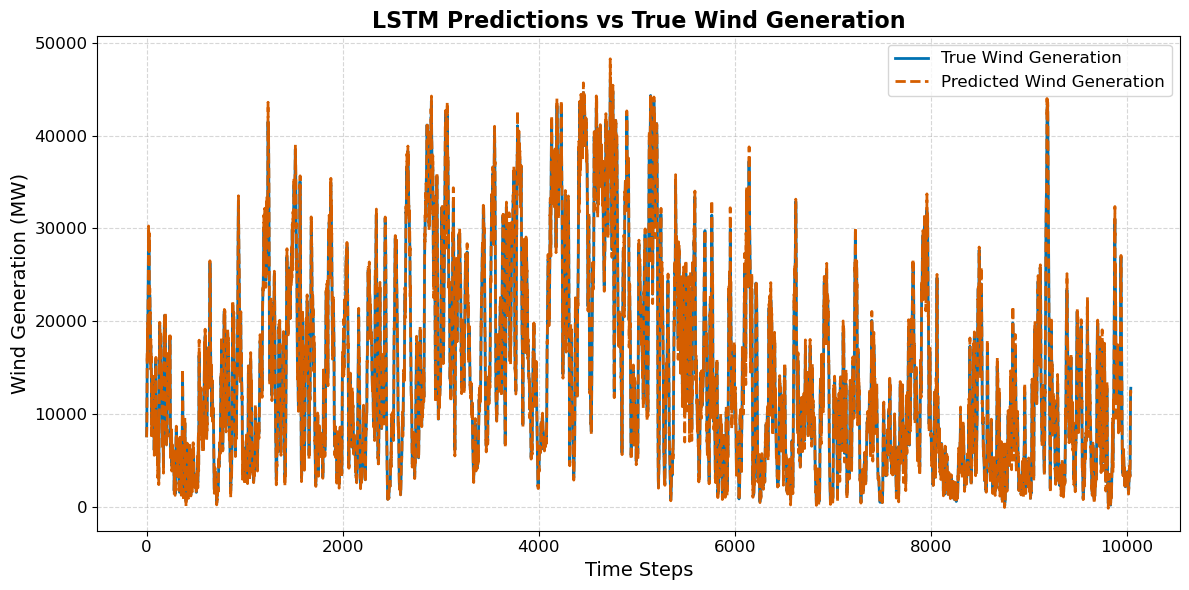

In [ ]:
y_pred = model.predict(X_test)

# Inverse scaling if needed
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

true_color = '#0072B2'      # blue
pred_color = '#D55E00'      # orange

plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label='True Wind Generation', color=true_color, linewidth=2)
plt.plot(y_pred_inv, label='Predicted Wind Generation', color=pred_color, linewidth=2, linestyle='--')

# Add grid, title, and labels
plt.title('LSTM Predictions vs True Wind Generation', fontsize=16, weight='bold')
plt.xlabel('Time Steps', fontsize=14)
plt.ylabel('Wind Generation (MW)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

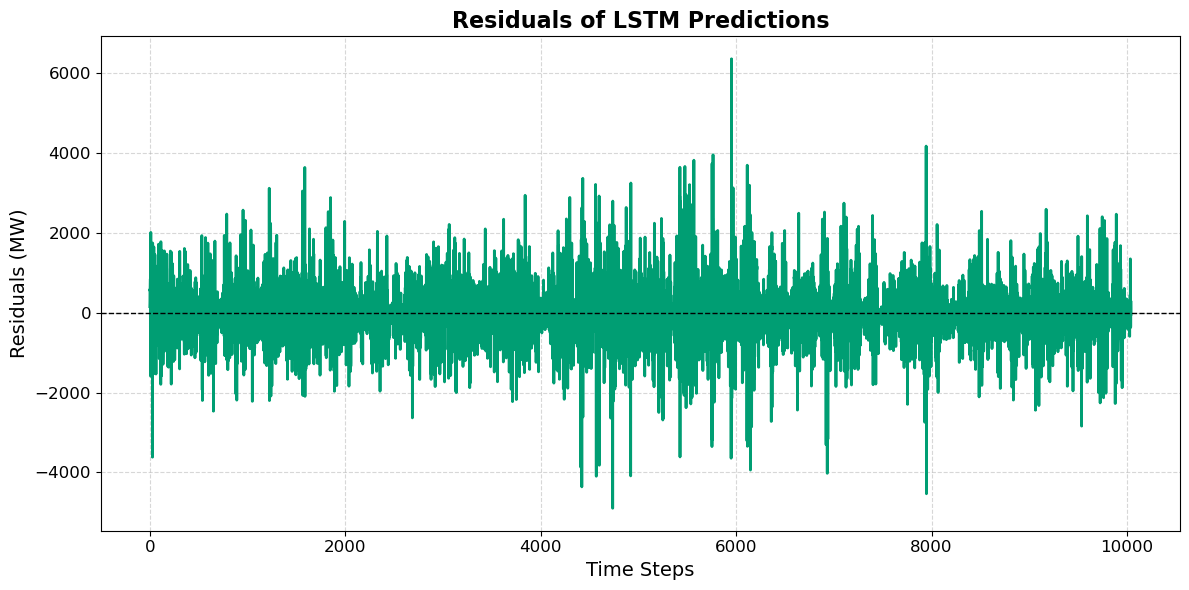

In [ ]:
# Calculate residuals
residuals = y_test_inv - y_pred_inv

plt.figure(figsize=(12,6))
plt.plot(residuals, color='#009E73', linewidth=2)  # color-blind friendly green
plt.axhline(0, color='black', linestyle='--', linewidth=1)  # reference line at 0

# Add labels, title, and grid
plt.title('Residuals of LSTM Predictions', fontsize=16, weight='bold')
plt.xlabel('Time Steps', fontsize=14)
plt.ylabel('Residuals (MW)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


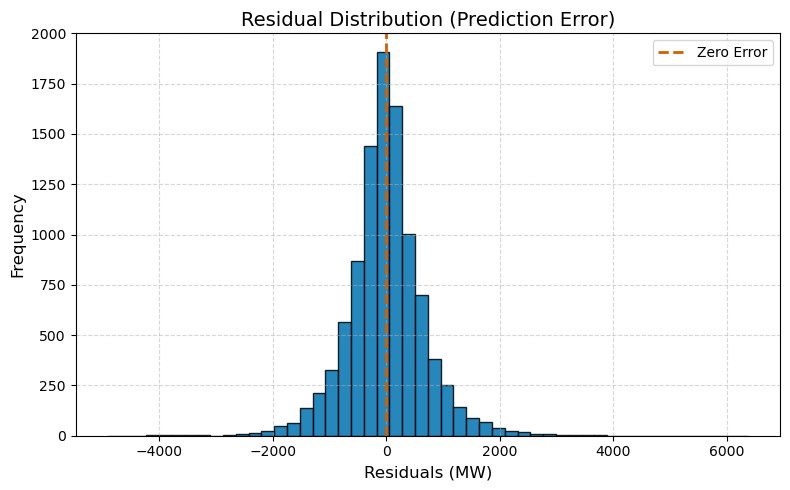

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=50,
    color='#0072B2',   # colorblind-friendly blue
    alpha=0.85,
    edgecolor='black'
)

plt.axvline(0, color='#D55E00', linestyle='--', linewidth=2, label='Zero Error')

plt.title('Residual Distribution (Prediction Error)', fontsize=14)
plt.xlabel('Residuals (MW)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

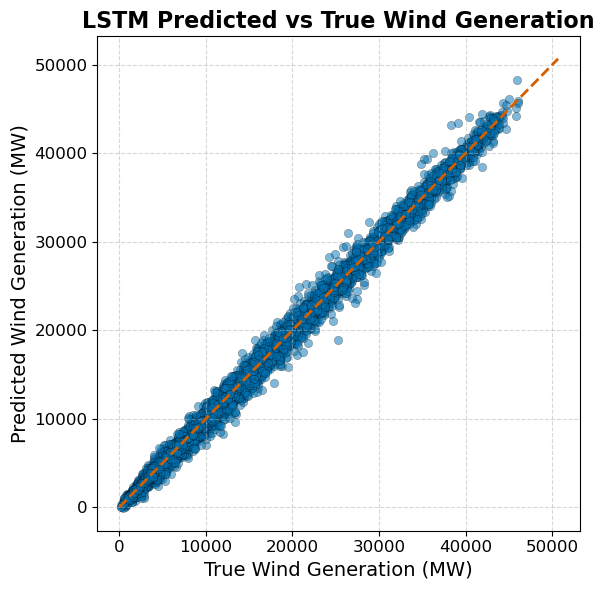

In [ ]:
plt.figure(figsize=(6,6))

# Scatter plot with color-blind friendly blue
plt.scatter(y_test_inv, y_pred_inv, alpha=0.5, color='#0072B2', edgecolor='k', linewidth=0.3)

# 45° reference line
max_val = max(y_test_inv.max(), y_pred_inv.max()) * 1.05
plt.plot([0, max_val], [0, max_val], color='#D55E00', linestyle='--', linewidth=2)  # orange-red, color-blind friendly

# Labels, title, grid
plt.xlabel('True Wind Generation (MW)', fontsize=14)
plt.ylabel('Predicted Wind Generation (MW)', fontsize=14)
plt.title('LSTM Predicted vs True Wind Generation', fontsize=16, weight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

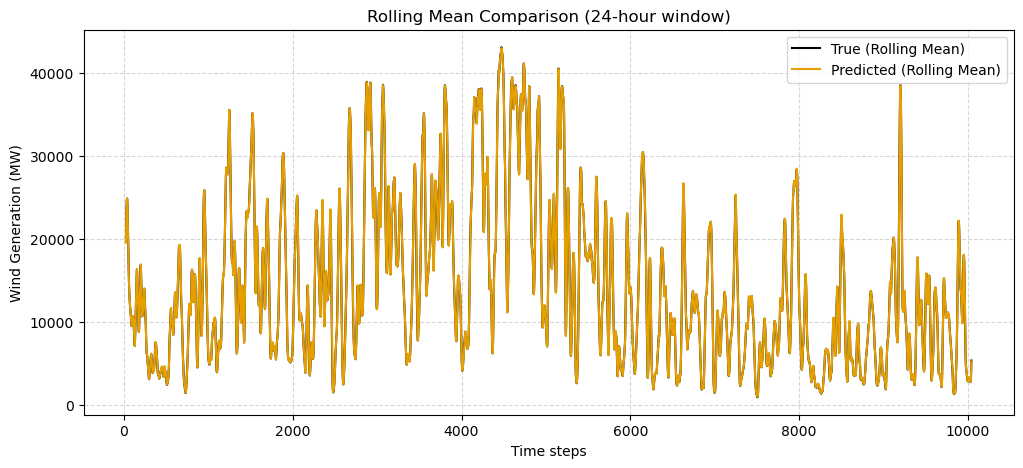

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert to Series
true_series = pd.Series(y_test_inv.flatten())
pred_series = pd.Series(y_pred_inv.flatten())

# Rolling average (smooth trends)
window = 24  # 1 day
true_roll = true_series.rolling(window).mean()
pred_roll = pred_series.rolling(window).mean()

plt.figure(figsize=(12,5))
plt.plot(true_roll, label='True (Rolling Mean)', color='#000000')   # black
plt.plot(pred_roll, label='Predicted (Rolling Mean)', color='#E69F00') # dark orange
plt.title('Rolling Mean Comparison (24-hour window)')
plt.xlabel('Time steps')
plt.ylabel('Wind Generation (MW)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))

print(f"MAE: {mae:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")

MAE: 487.75 MW
RMSE: 693.72 MW


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test_inv, y_pred_inv)
print("R² Score:", r2)

R² Score: 0.9956268711277247


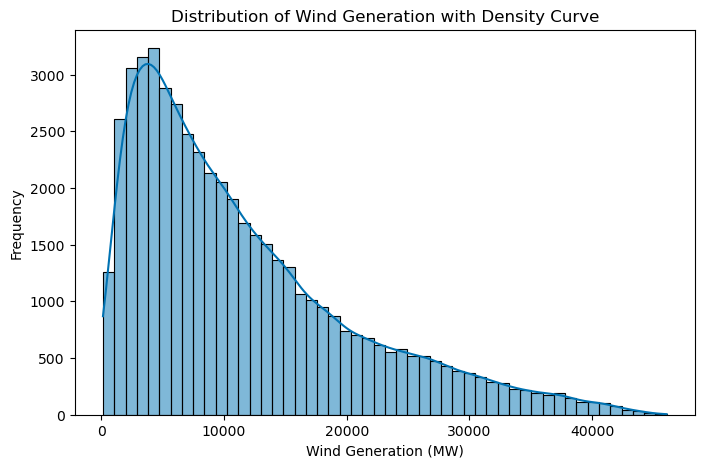

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['DE_wind_generation_actual'], bins=50, kde=True, color='#0072B2')
plt.title('Distribution of Wind Generation with Density Curve')
plt.xlabel('Wind Generation (MW)')
plt.ylabel('Frequency')
plt.show()

## 5. Results and Evaluation

### 5.1 Performance Metrics

* Mean Absolute Error (MAE): 487.75 MW
* Root Mean Squared Error (RMSE): 693.72 MW
* R² Score: 0.9956

These results indicate that the model achieves relatively low prediction error compared to the scale of wind generation, with a very high R² showing excellent variance explanation.

### 5.2 Prediction Analysis

* The model adequately reflects general trends in wind power production.
* There is a good match between predicted and actual figures.
* Larger discrepancies arise during peak production times, a phenomenon frequently observed in LSTM models owing to drastic changes.

### 5.3 Residual Analysis

* The residuals have a mean of zero, indicating that predictions are unbiased.
* Larger residuals can be noticed when there are extremes in the data set, especially during peak times of high wind production.
* The residuals appear to be symmetrically distributed and have a narrow range.

---

## 6. Discussion

The LSTM network is effective for identifying time-series patterns within the wind power generation dataset. However, there are some drawbacks associated with the model:

* It does not effectively handle sudden spikes in generation.
* Only one feature was considered, making the model univariate. Other factors such as weather may affect wind power generation and thus must be considered.

Possible enhancements to the current model:

* Incorporate multivariate features such as wind speed, temperature, and weather forecast.
* Try deeper networks like stacking LSTM layers or using advanced models like Temporal Fusion Transformers.

---

## 7. Conclusion

In this research, an LSTM model was successfully implemented to predict the output wind power for Germany. The performance was excellent with an excellent correlation coefficient R² suggesting that the model predicted the wind power accurately.

Areas of future research can be considered in terms of including other variables into the prediction process, improving the complexity of the model, and researching other forecasting models.

---

## References

* Open Power System Data (2020). Time series 60min single index for Germany.
  [https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv](https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv)
